In [ ]:
# Name: Tshepo Molebiemang
# Student #: u28174862
# Course: MIT801
# Date: 23 March 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score, precision_recall_curve
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

import os
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
#1. LOAD DATA

print("\n[1/13] Loading dataset from local CSV...")

csv_path = os.path.expanduser('~\Desktop\diabetic_data.csv')

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"CSV not found at: {csv_path}")

df = pd.read_csv(csv_path, na_values='?')

print(f"      File found at: {csv_path}")
print(f"      Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")


[1/13] Loading dataset from local CSV...
      File found at: C:\Users\Tshepo\Desktop\diabetic_data.csv
      Loaded: 101,766 rows × 50 cols


In [3]:
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),NaN,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),NaN,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),NaN,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),NaN,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),NaN,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
#2. GROUPING AND TEMPORAL SPLITTING

print("\n[2/13] Building temporal train/test split...")

# Sort all encounters by encounter_id - approximates time
df_sorted = df.sort_values('encounter_id').reset_index(drop=True)

# For each patient, find their first encounter's position
patient_first_encounter = (
    df_sorted.groupby('patient_nbr')['encounter_id']
    .min()
    .reset_index()
    .rename(columns={'encounter_id': 'first_encounter_id'})
    .sort_values('first_encounter_id')
    .reset_index(drop=True)
)

# 80/20 cutoff on the sorted patient list
cutoff_idx = int(len(patient_first_encounter) * 0.8)
cutoff_enc = patient_first_encounter.loc[cutoff_idx, 'first_encounter_id']

train_patients = set(patient_first_encounter.loc[:cutoff_idx - 1, 'patient_nbr'])
test_patients  = set(patient_first_encounter.loc[cutoff_idx:,     'patient_nbr'])

train_mask = df['patient_nbr'].isin(train_patients)
test_mask  = df['patient_nbr'].isin(test_patients)

df_train = df[train_mask].copy()
df_test  = df[test_mask].copy()

overlap = train_patients & test_patients
print(f"       Train patients : {len(train_patients):,}  |  encounters: {len(df_train):,}")
print(f"       Test  patients : {len(test_patients):,}  |  encounters: {len(df_test):,}")
print(f"       Patient overlap: {len(overlap)} (must be 0)")
assert len(overlap) == 0, "Patient leakage detected!"

train_enc_range = (df_train['encounter_id'].min(), df_train['encounter_id'].max())
test_enc_range  = (df_test['encounter_id'].min(),  df_test['encounter_id'].max())

print(f"\n      Cutoff encounter_id  : {cutoff_enc:,}")
print(f"      Train encounter range: {train_enc_range[0]:,} – {train_enc_range[1]:,}")
print(f"      Test encounter range : {test_enc_range[0]:,} – {test_enc_range[1]:,}")


[2/13] Building temporal train/test split...
       Train patients : 57,214  |  encounters: 84,442
       Test  patients : 14,304  |  encounters: 17,324
       Patient overlap: 0 (must be 0)

      Cutoff encounter_id  : 241,370,898
      Train encounter range: 12,522 – 443,857,166
      Test encounter range : 241,370,898 – 443,867,222


In [4]:
#3. PREPROCESSING

print("\n[3/13] Preprocessing features...")

# Target: binary — readmitted <30 days (1) vs everything else (0)
for d in [df_train, df_test]:
    d['target'] = (d['readmitted'] == '<30').astype(int)

print(f"      Train target rate: {df_train['target'].mean()*100:.1f}%  (<30 day readmits)")
print(f"      Test target rate : {df_test['target'].mean()*100:.1f}%")

# Drop ID / leakage / high-missingness columns
drop_cols = ['readmitted', 'encounter_id', 'patient_nbr',
             'payer_code', 'medical_specialty', 'weight']

def prep_features(d):
    d = d.drop(columns=[c for c in drop_cols if c in d.columns])
    return d

df_train = prep_features(df_train)
df_test  = prep_features(df_test)

X_train_raw = df_train.drop(columns='target')
y_train     = df_train['target']
X_test_raw  = df_test.drop(columns='target')
y_test      = df_test['target']

cat_cols = X_train_raw.select_dtypes(include='object').columns.tolist()

# Ordinal mapping for age
age_map = {a: i for i, a in enumerate([
    '[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
    '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'])}

X_train_raw['age'] = X_train_raw['age'].map(age_map).fillna(5)
X_test_raw['age']  = X_test_raw['age'].map(age_map).fillna(5)

# Target-encode all remaining categoricals
cat_cols = [c for c in cat_cols if c != 'age']

for col in cat_cols:
    X_train_raw[col] = X_train_raw[col].fillna('missing')
    X_test_raw[col]  = X_test_raw[col].fillna('missing')

te = TargetEncoder(smooth='auto', target_type='binary')
te.fit(X_train_raw[cat_cols], y_train)
X_train_raw[cat_cols] = te.transform(X_train_raw[cat_cols])
X_test_raw[cat_cols]  = te.transform(X_test_raw[cat_cols])

print(f"      Numeric features   : {len(X_train_raw.columns) - len(cat_cols)}")
print(f"      Target-encoded cols: {len(cat_cols)}")


[3/13] Preprocessing features...
      Train target rate: 11.6%  (<30 day readmits)
      Test target rate : 8.8%
      Numeric features   : 12
      Target-encoded cols: 32


In [5]:
#4. TRAIN/VALIDATION SPLIT + CLASS BALANCING

print("\n[4/13] Splitting training data into Train/Validation before balancing...")

X_tr_final, X_val, y_tr_final, y_val = train_test_split(
    X_train_raw, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

# Oversample only the train portion, validation stays untouched
train_temp = X_tr_final.copy()
train_temp['target'] = y_tr_final.values

majority    = train_temp[train_temp['target'] == 0]
minority    = train_temp[train_temp['target'] == 1]
minority_up = resample(minority, replace=True, n_samples=len(majority), random_state=42)
balanced_train = pd.concat([majority, minority_up])

X_tr_bal = balanced_train.drop(columns='target')
y_tr_bal = balanced_train['target']

print(f"      Original Train Size: {len(X_tr_final):,}")
print(f"      Balanced Train Size: {len(X_tr_bal):,} (50/50 split)")
print(f"      Validation Size    : {len(X_val):,} (real ~{y_val.mean()*100:.1f}% distribution)")
print(f"      Test Size          : {len(X_test_raw):,} (real ~{y_test.mean()*100:.1f}% distribution)")


[4/13] Splitting training data into Train/Validation before balancing...
      Original Train Size: 71,775
      Balanced Train Size: 126,840 (50/50 split)
      Validation Size    : 12,667 (real ~11.6% distribution)
      Test Size          : 17,324 (real ~8.8% distribution)


In [6]:
#5. DUMMY CLASSIFIER

print("\n[5/13] Training DummyClassifier ...")

dummy = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('dummy',   DummyClassifier(strategy='most_frequent')),
])

dummy.fit(X_tr_bal, y_tr_bal)

y_proba_val_d  = dummy.predict_proba(X_val)[:, 1]
y_proba_test_d = dummy.predict_proba(X_test_raw)[:, 1]

pr_auc_val_d  = average_precision_score(y_val, y_proba_val_d)
pr_auc_test_d = average_precision_score(y_test, y_proba_test_d)

roc_auc_val_d  = 0.50
roc_auc_test_d = 0.50

print(f"\n                  Val   │   Test      ")
print(f"      ─────────┼────────┼────────")
print(f"       PR-AUC  │ {pr_auc_val_d:.4f} │ {pr_auc_test_d:.4f}")
print(f"       ROC-AUC │ {roc_auc_val_d:.4f} │ {roc_auc_test_d:.4f}")


[5/13] Training DummyClassifier ...

                  Val   │   Test      
      ─────────┼────────┼────────
       PR-AUC  │ 0.1164 │ 0.0881
       ROC-AUC │ 0.5000 │ 0.5000


In [13]:
#6. SGD BASELINE PIPELINE

print("\n[6/13] Building baseline SGD pipeline...")

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('sgd',     SGDClassifier(
        loss='log_loss',
        penalty='elasticnet',
        alpha=0.0001,
        l1_ratio=0.15,
        max_iter=1000,
        tol=1e-3,
        random_state=42,
        class_weight=None,
        learning_rate='constant',
        eta0=1e-2,
        n_jobs=-1,
        shuffle=True,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
    ))
])


[6/13] Building baseline SGD pipeline...


In [14]:
#7. BASELINE CROSS-VALIDATION

print("\n[7/13] Running 10-fold stratified CV on training set...")

cv = StratifiedKFold(n_splits=10,
                     shuffle=True,
                     random_state=42)

# on training fold only
cv_scores = cross_val_score(pipeline, X_tr_bal, y_tr_bal, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"      CV ROC-AUC scores: {cv_scores.round(4)}")
print(f"      Mean ± Std       : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


[7/13] Running 10-fold stratified CV on training set...
      CV ROC-AUC scores: [0.6769 0.6667 0.675  0.6783 0.663  0.6847 0.6753 0.6859 0.6743 0.6792]
      Mean ± Std       : 0.6759 ± 0.0067


In [15]:
#8. BASELINE EVALUATION

print("\n[8/13] Evaluating baseline model...")

start_time = time.time()
pipeline.fit(X_tr_bal, y_tr_bal)
baseline_train_time = time.time() - start_time
print(f"\n      Training Time: {baseline_train_time:.4f}")

y_proba_train = pipeline.predict_proba(X_tr_bal)[:, 1]
y_proba_val   = pipeline.predict_proba(X_val)[:, 1]
y_proba_test  = pipeline.predict_proba(X_test_raw)[:, 1]
y_pred_test   = pipeline.predict(X_test_raw)

pr_auc_train = average_precision_score(y_tr_bal, y_proba_train)
pr_auc_val   = average_precision_score(y_val, y_proba_val)
pr_auc_test  = average_precision_score(y_test, y_proba_test)

print(f"\n      Train PR-AUC     : {pr_auc_train:.4f}")
print(f"      Validation PR-AUC: {pr_auc_val:.4f}")
print(f"      Test PR-AUC      : {pr_auc_test:.4f}")

precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_proba_val)

mask = precision_curve >= 0.8
recall_at_p80 = recall_curve[mask].max() if mask.any() else 0.0
print(f"\n      Validation Recall @ Precision ≥ 0.8: {recall_at_p80:.4f}")

roc_auc = roc_auc_score(y_test, y_proba_test)
report  = classification_report(y_test, y_pred_test, target_names=['Not <30', '<30 days'])

print(f"\n      Test ROC-AUC: {roc_auc:.4f}")
print(f"\n      Classification Report:\n{report}")


[8/13] Evaluating baseline model...

      Training Time: 1.6086

      Train PR-AUC     : 0.6734
      Validation PR-AUC: 0.2405
      Test PR-AUC      : 0.1376

      Validation Recall @ Precision ≥ 0.8: 0.0102

      Test ROC-AUC: 0.6093

      Classification Report:
              precision    recall  f1-score   support

     Not <30       0.93      0.76      0.83     15797
    <30 days       0.13      0.38      0.19      1527

    accuracy                           0.72     17324
   macro avg       0.53      0.57      0.51     17324
weighted avg       0.86      0.72      0.78     17324



In [16]:
#9. GRID SEARCH CV

print("\n[9/13] Running grid search with 10-fold stratified CV...")

param_grid = [
    {
        'sgd__eta0':    [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 1e-1],
        'sgd__alpha':   [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        'sgd__penalty': ['l1', 'l2'],
    },
    {
        'sgd__eta0':     [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 1e-1],
        'sgd__alpha':    [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        'sgd__penalty':  ['elasticnet'],
        'sgd__l1_ratio': [0.15, 0.5, 0.75],
    },
]

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    refit=True,
)

start_time = time.time()
grid_search.fit(X_tr_bal, y_tr_bal)
grid_train_time = time.time() - start_time
grid_train_time_min = grid_train_time / 60 

print(f"\n      Grid search time: {grid_train_time:.2f}s / {grid_train_time_min:0.2f}min")
print(f"      Best CV ROC-AUC : {grid_search.best_score_:.4f}")
print(f"      Best params     : {grid_search.best_params_}")

best_idx = grid_search.best_index_
cv_mean  = grid_search.cv_results_['mean_test_score'][best_idx]
cv_std   = grid_search.cv_results_['std_test_score'][best_idx]
print(f"      Mean ± Std       : {cv_mean:.4f} ± {cv_std:.4f}")

# Top 5 configurations
results_df = pd.DataFrame(grid_search.cv_results_)
results_df['total_time'] = (results_df['mean_fit_time'] + results_df['mean_score_time']) * cv.n_splits
results_df = results_df.sort_values('rank_test_score').head(5)

print(f"\n      Top 5 configurations:")
for i, row in results_df.iterrows():
    print(f"      #{int(row['rank_test_score'])}  "
          f"ROC-AUC: {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}  "
          f"| time: {row['total_time']:.2f}s  "
          f"| {row['params']}")


[9/13] Running grid search with 10-fold stratified CV...
Fitting 10 folds for each of 180 candidates, totalling 1800 fits

      Grid search time: 783.34s / 13.06min
      Best CV ROC-AUC : 0.6839
      Best params     : {'sgd__alpha': 0.001, 'sgd__eta0': 0.0001, 'sgd__l1_ratio': 0.15, 'sgd__penalty': 'elasticnet'}
      Mean ± Std       : 0.6839 ± 0.0061

      Top 5 configurations:
      #1  ROC-AUC: 0.6839 ± 0.0061  | time: 25.63s  | {'sgd__alpha': 0.001, 'sgd__eta0': 0.0001, 'sgd__l1_ratio': 0.15, 'sgd__penalty': 'elasticnet'}
      #2  ROC-AUC: 0.6839 ± 0.0061  | time: 27.77s  | {'sgd__alpha': 1e-06, 'sgd__eta0': 0.0001, 'sgd__l1_ratio': 0.5, 'sgd__penalty': 'elasticnet'}
      #3  ROC-AUC: 0.6839 ± 0.0061  | time: 31.34s  | {'sgd__alpha': 1e-06, 'sgd__eta0': 0.0001, 'sgd__penalty': 'l2'}
      #4  ROC-AUC: 0.6839 ± 0.0061  | time: 28.54s  | {'sgd__alpha': 1e-06, 'sgd__eta0': 0.0001, 'sgd__l1_ratio': 0.15, 'sgd__penalty': 'elasticnet'}
      #5  ROC-AUC: 0.6839 ± 0.0061  | time: 

In [19]:
#10. GRIDSEARCH MODEL EVALUATION

print("\n[10/13] Evaluating gridsearch model...")

tuned_pipeline = grid_search.best_estimator_

y_proba_train_t = tuned_pipeline.predict_proba(X_tr_bal)[:, 1]
y_proba_val_t   = tuned_pipeline.predict_proba(X_val)[:, 1]
y_proba_test_t  = tuned_pipeline.predict_proba(X_test_raw)[:, 1]
y_pred_test_t   = tuned_pipeline.predict(X_test_raw)

pr_auc_train_t = average_precision_score(y_tr_bal, y_proba_train_t)
pr_auc_val_t   = average_precision_score(y_val, y_proba_val_t)
pr_auc_test_t  = average_precision_score(y_test, y_proba_test_t)

print(f"\n      Train PR-AUC     : {pr_auc_train_t:.4f}")
print(f"      Validation PR-AUC: {pr_auc_val_t:.4f}")
print(f"      Test  PR-AUC     : {pr_auc_test_t:.4f}")

precision_curve_t, recall_curve_t, _ = precision_recall_curve(y_val, y_proba_val_t)
mask_t = precision_curve_t >= 0.8
recall_at_p80_t = recall_curve_t[mask_t].max() if mask_t.any() else 0.0
print(f"      Val Recall @ Precision ≥ 0.8 : {recall_at_p80_t:.4f}")

roc_auc_t = roc_auc_score(y_test, y_proba_test_t)
report_t  = classification_report(y_test, y_pred_test_t, target_names=['Not <30', '<30 days'])

print(f"\n      Test ROC-AUC: {roc_auc_t:.4f}")
print(f"\n      Classification Report (Grid):\n{report_t}")

print("     ** BASELINE vs GRIDSEARCH TUNED COMPARISON **")
print(f"\n                            Baseline    Gridsearch")
print(f"      Train PR-AUC        : {pr_auc_train:.4f}      {pr_auc_train_t:.4f}")
print(f"      Val PR-AUC          : {pr_auc_val:.4f}      {pr_auc_val_t:.4f}")
print(f"      Test PR-AUC         : {pr_auc_test:.4f}      {pr_auc_test_t:.4f}")
print(f"      Test ROC-AUC        : {roc_auc:.4f}      {roc_auc_t:.4f}")
print(f"      Val Recall @ P ≥ 0.8: {recall_at_p80:.4f}      {recall_at_p80_t:.4f}")


[10/13] Evaluating gridsearch model...

      Train PR-AUC     : 0.6795
      Validation PR-AUC: 0.2452
      Test  PR-AUC     : 0.1421
      Val Recall @ Precision ≥ 0.8 : 0.0115

      Test ROC-AUC: 0.6210

      Classification Report (Grid):
              precision    recall  f1-score   support

     Not <30       0.93      0.71      0.80     15797
    <30 days       0.13      0.46      0.21      1527

    accuracy                           0.69     17324
   macro avg       0.53      0.58      0.51     17324
weighted avg       0.86      0.69      0.75     17324

     ** BASELINE vs GRIDSEARCH TUNED COMPARISON **

                            Baseline    Gridsearch
      Train PR-AUC        : 0.6734      0.6795
      Val PR-AUC          : 0.2405      0.2452
      Test PR-AUC         : 0.1376      0.1421
      Test ROC-AUC        : 0.6093      0.6210
      Val Recall @ P ≥ 0.8: 0.0102      0.0115


In [20]:
#11. HALVING GRID SEARCH

print("\n[11/13] Running HalvingGridSearchCV on same grid... \n")

halving_search = HalvingGridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    factor=3,
    resource='n_samples',
    n_jobs=-1,
    verbose=1,
    refit=True,
    random_state=42,
)

start_time = time.time()
halving_search.fit(X_tr_bal, y_tr_bal)
halving_train_time = time.time() - start_time
halving_train_time_min = halving_train_time / 60 

halving_results_df = pd.DataFrame(halving_search.cv_results_)
halving_n_evals = halving_results_df['mean_test_score'].notna().sum() * cv.n_splits

print(f"\n      Halving search time: {halving_train_time:.2f}s / {halving_train_time_min:0.2f}min")
print(f"      Best CV ROC-AUC   : {halving_search.best_score_:.4f}")
print(f"      Best params        : {halving_search.best_params_}")
print(f"      Model evaluations  : {halving_n_evals}")
print(f"      Iterations (rounds): {halving_search.n_iterations_}")

# top 5 configurations
halving_top5 = halving_results_df.sort_values('rank_test_score').head(5)

print(f"\n      Top 5 configurations:")
for _, row in halving_top5.iterrows():
    print(f"      #{int(row['rank_test_score'])}  "
          f"ROC-AUC: {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}  "
          f"| {row['params']}")

halving_pipeline = halving_search.best_estimator_

y_proba_train_h = halving_pipeline.predict_proba(X_tr_bal)[:, 1]
y_proba_val_h   = halving_pipeline.predict_proba(X_val)[:, 1]
y_proba_test_h  = halving_pipeline.predict_proba(X_test_raw)[:, 1]
y_pred_test_h   = halving_pipeline.predict(X_test_raw)

pr_auc_train_h = average_precision_score(y_tr_bal, y_proba_train_h)
pr_auc_val_h   = average_precision_score(y_val, y_proba_val_h)
pr_auc_test_h  = average_precision_score(y_test, y_proba_test_h)

print(f"\n      Train PR-AUC     : {pr_auc_train_h:.4f}")
print(f"      Validation PR-AUC: {pr_auc_val_h:.4f}")
print(f"      Test PR-AUC      : {pr_auc_test_h:.4f}")

precision_curve_h, recall_curve_h, _ = precision_recall_curve(y_val, y_proba_val_h)
mask_h = precision_curve_h >= 0.8
recall_at_p80_h = recall_curve_h[mask_h].max() if mask_h.any() else 0.0
print(f"      Val Recall @ Precision ≥ 0.8 : {recall_at_p80_h:.4f}")

roc_auc_h = roc_auc_score(y_test, y_proba_test_h)
report_h  = classification_report(y_test, y_pred_test_h, target_names=['Not <30', '<30 days'])

print(f"\n      Test ROC-AUC: {roc_auc_h:.4f}")
print(f"\n      Classification Report (Halving):\n{report_h}")

print(" ** GRID SEARCH vs HALVING GRID SEARCH COMPARISON **")

grid_n_evals = len(grid_search.cv_results_['mean_test_score']) * cv.n_splits
print(f"\n                     GridSearch  Halving")
print(f"      Train time(s): {grid_train_time:.2f}      {halving_train_time:.2f}")
print(f"      Model evals  : {grid_n_evals}        {halving_n_evals}")
print(f"      Best ROC-AUC : {grid_search.best_score_:.4f}      {halving_search.best_score_:.4f}")
print(f"      Val PR-AUC   : {pr_auc_val_t:.4f}      {pr_auc_val_h:.4f}")
print(f"      Test PR-AUC  : {pr_auc_test_t:.4f}      {pr_auc_test_h:.4f}")
print(f"      Test ROC-AUC : {roc_auc_t:.4f}      {roc_auc_h:.4f}")

speedup = grid_train_time / halving_train_time if halving_train_time > 0 else float('inf')
print(f"      Speedup      : {speedup:.1f}×")


[11/13] Running HalvingGridSearchCV on same grid... 

n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 1565
max_resources_: 126840
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 180
n_resources: 1565
Fitting 10 folds for each of 180 candidates, totalling 1800 fits
----------
iter: 1
n_candidates: 60
n_resources: 4695
Fitting 10 folds for each of 60 candidates, totalling 600 fits
----------
iter: 2
n_candidates: 20
n_resources: 14085
Fitting 10 folds for each of 20 candidates, totalling 200 fits
----------
iter: 3
n_candidates: 7
n_resources: 42255
Fitting 10 folds for each of 7 candidates, totalling 70 fits
----------
iter: 4
n_candidates: 3
n_resources: 126765
Fitting 10 folds for each of 3 candidates, totalling 30 fits

      Halving search time: 90.98s / 1.52min
      Best CV ROC-AUC   : 0.6831
      Best params        : {'sgd__alpha': 0.01, 'sgd__eta0': 0.0001, 'sgd__l1_ratio': 0.5, 'sgd__penalty': 'elasticnet'}
      Mode

In [21]:
#12. BAYESIAN OPTIMISATION

print("\n[12/13] Running 40-trial Bayesian Optimisation...")

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    eta0     = trial.suggest_float('eta0', 1e-5, 1e-1, log=True)
    alpha    = trial.suggest_float('alpha', 1e-7, 1e-2, log=True)
    penalty  = trial.suggest_categorical('penalty', ['l1', 'l2'])
    lr_sched = trial.suggest_categorical('learning_rate', ['constant', 'optimal', 'invscaling', 'adaptive'])

    sgd_params = dict(
        loss='log_loss',
        penalty=penalty,
        alpha=alpha,
        max_iter=1000,
        tol=1e-3,
        random_state=42,
        class_weight=None,
        learning_rate=lr_sched,
        eta0=eta0,
        shuffle=True,
        n_jobs=-1,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
    )

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('sgd',     SGDClassifier(**sgd_params)),
    ])

    pipe.fit(X_tr_bal, y_tr_bal)
    y_proba_val_opt = pipe.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_proba_val_opt)

start_time = time.time()
study = optuna.create_study(direction='maximize', study_name='sgd_pr_auc')
study.optimize(objective, n_trials=40)
optuna_time = time.time() - start_time
optuna_time_min = optuna_time / 60

print(f"\n      Optuna search time: {optuna_time:.2f}s / {optuna_time_min:0.2f}min")
print(f"      Best Val PR-AUC   : {study.best_value:.4f}")
print(f"      Best params       : {study.best_params}")

trials_df = study.trials_dataframe().sort_values('value', ascending=False).head(5)
print(f"\n      Top 5 trials:")
for _, row in trials_df.iterrows():
    print(f"      #{int(row['number']):>2}  Val PR-AUC: {row['value']:.4f}  | "
          f"eta0={row['params_eta0']:.2e}, alpha={row['params_alpha']:.2e}, "
          f"penalty={row['params_penalty']}, lr={row['params_learning_rate']}")


[12/13] Running 40-trial Bayesian Optimisation...

      Optuna search time: 98.35s / 1.64min
      Best Val PR-AUC   : 0.2453
      Best params       : {'eta0': 0.034071985758113765, 'alpha': 0.0038708959344997055, 'penalty': 'l1', 'learning_rate': 'optimal'}

      Top 5 trials:
      #28  Val PR-AUC: 0.2453  | eta0=3.41e-02, alpha=3.87e-03, penalty=l1, lr=optimal
      #24  Val PR-AUC: 0.2453  | eta0=8.02e-03, alpha=1.05e-03, penalty=l1, lr=adaptive
      #31  Val PR-AUC: 0.2452  | eta0=9.52e-02, alpha=4.25e-03, penalty=l1, lr=optimal
      #30  Val PR-AUC: 0.2452  | eta0=8.64e-02, alpha=4.64e-03, penalty=l1, lr=optimal
      #27  Val PR-AUC: 0.2452  | eta0=3.39e-02, alpha=3.54e-03, penalty=l1, lr=adaptive


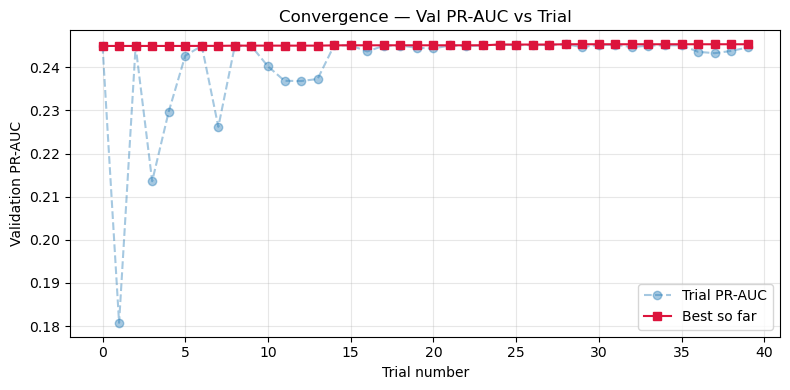

In [22]:
# Convergence plot: best score vs trial number

trial_numbers = [t.number for t in study.trials]
trial_values  = [t.value for t in study.trials]
best_so_far   = [max(trial_values[:i+1]) for i in range(len(trial_values))]

plt.figure(figsize=(8, 4))
plt.plot(trial_numbers, trial_values, 'o--', alpha=0.4, label='Trial PR-AUC')
plt.plot(trial_numbers, best_so_far, 's-', color='crimson', label='Best so far')
plt.xlabel('Trial number')
plt.ylabel('Validation PR-AUC')
plt.title('Convergence — Val PR-AUC vs Trial')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
#13. BEST OPTUNA MODEL EVALUATION

print("\n[13/13] Evaluating best Optuna model...")

best_params = study.best_params

optuna_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('sgd',     SGDClassifier(
        loss='log_loss',
        penalty=best_params['penalty'],
        alpha=best_params['alpha'],
        max_iter=1000,
        tol=1e-3,
        random_state=42,
        class_weight=None,
        learning_rate=best_params['learning_rate'],
        eta0=best_params['eta0'],
        shuffle=True,
        n_jobs=-1,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
    ))
])

optuna_pipeline.fit(X_tr_bal, y_tr_bal)

y_proba_train_o = optuna_pipeline.predict_proba(X_tr_bal)[:, 1]
y_proba_val_o   = optuna_pipeline.predict_proba(X_val)[:, 1]
y_proba_test_o  = optuna_pipeline.predict_proba(X_test_raw)[:, 1]
y_pred_test_o   = optuna_pipeline.predict(X_test_raw)

pr_auc_train_o = average_precision_score(y_tr_bal, y_proba_train_o)
pr_auc_val_o   = average_precision_score(y_val, y_proba_val_o)
pr_auc_test_o  = average_precision_score(y_test, y_proba_test_o)

print(f"\n      Train PR-AUC     : {pr_auc_train_o:.4f}")
print(f"      Validation PR-AUC: {pr_auc_val_o:.4f}")
print(f"      Test PR-AUC      : {pr_auc_test_o:.4f}")

precision_curve_o, recall_curve_o, _ = precision_recall_curve(y_val, y_proba_val_o)
mask_o = precision_curve_o >= 0.8
recall_at_p80_o = recall_curve_o[mask_o].max() if mask_o.any() else 0.0
print(f"      Val Recall @ Precision ≥ 0.8 : {recall_at_p80_o:.4f}")

roc_auc_o = roc_auc_score(y_test, y_proba_test_o)
report_o  = classification_report(y_test, y_pred_test_o, target_names=['Not <30', '<30 days'])

print(f"\n      Test ROC-AUC: {roc_auc_o:.4f}")
print(f"\n      Classification Report (Optuna):\n{report_o}")

print("\n")
print("       *** BASELINE vs GRID SEARCH vs OPTUNA COMPARISON ***")
print(f"\n                     Baseline    GridSearch  Optuna")
print(f"      Model evals  : 1           {grid_n_evals}        {len(study.trials)}")
print(f"      Train time(s): {baseline_train_time:.2f}        {grid_train_time:.2f}      {optuna_time:.2f}")
print(f"      Test ROC-AUC : {roc_auc:.4f}      {roc_auc_t:.4f}      {roc_auc_o:.4f}")
print(f"      Train PR-AUC : {pr_auc_train:.4f}      {pr_auc_train_t:.4f}      {pr_auc_train_o:.4f}")
print(f"      Val PR-AUC   : {pr_auc_val:.4f}      {pr_auc_val_t:.4f}      {pr_auc_val_o:.4f}")
print(f"      Test PR-AUC  : {pr_auc_test:.4f}      {pr_auc_test_t:.4f}      {pr_auc_test_o:.4f}")


[13/13] Evaluating best Optuna model...

      Train PR-AUC     : 0.6784
      Validation PR-AUC: 0.2453
      Test PR-AUC      : 0.1424
      Val Recall @ Precision ≥ 0.8 : 0.0081

      Test ROC-AUC: 0.6205

      Classification Report (Optuna):
              precision    recall  f1-score   support

     Not <30       0.93      0.71      0.81     15797
    <30 days       0.13      0.46      0.20      1527

    accuracy                           0.69     17324
   macro avg       0.53      0.58      0.50     17324
weighted avg       0.86      0.69      0.75     17324



       *** BASELINE vs GRID SEARCH vs OPTUNA COMPARISON ***

                     Baseline    GridSearch  Optuna
      Model evals  : 1           1800        40
      Train time(s): 1.61        783.34      98.35
      Test ROC-AUC : 0.6093      0.6210      0.6205
      Train PR-AUC : 0.6734      0.6795      0.6784
      Val PR-AUC   : 0.2405      0.2452      0.2453
      Test PR-AUC  : 0.1376      0.1421      0.1424
